# Notebook 00 - Data Loading and Signal Understanding

## Goal
Understand raw speech as a discrete-time signal before any preprocessing.


## Agenda
- Load one audio file
- Compute sample count and duration
- Plot waveform with time axis
- Interpret silence and active speech


## Concept and Math

Digital audio stores sampled values x[n] = x(nT_s), where T_s = 1/f_s.
If total samples are N and sampling rate is f_s, duration is T = N/f_s.
Nyquist intuition: represent up to f_max by choosing f_s >= 2 f_max.


Using: ..\dataset\flac_D\D_0000000001.flac
sample_rate = 16000 Hz
num_samples = 114960
duration = 7.185 sec


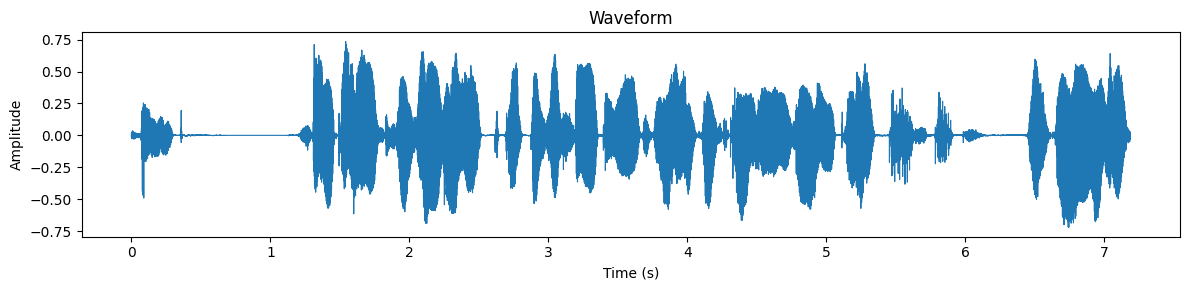

In [1]:
from pathlib import Path
import numpy as np
import librosa as lb
import librosa.display
import matplotlib.pyplot as plt

DATA_ROOT = Path("../dataset")

audio_files = sorted(DATA_ROOT.rglob("*.flac")) + sorted(DATA_ROOT.rglob("*.wav"))
if not audio_files:
    raise FileNotFoundError("No .flac or .wav found under ../dataset")

audio_path = audio_files[0]
print(f"Using: {audio_path}")

waveform, sr = lb.load(audio_path, sr=None, mono=True)
N = len(waveform)
duration = N / sr

print(f"sample_rate = {sr} Hz")
print(f"num_samples = {N}")
print(f"duration = {duration:.3f} sec")

t = np.arange(N) / sr
plt.figure(figsize=(12, 3))
plt.plot(t, waveform, linewidth=0.8)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


## PyTorch Equivalent Snippet
Understand the librosa block first, then map it to this snippet.


In [2]:
import torchaudio

wave_t, sr_t = torchaudio.load(str(audio_path))
# torchaudio format: [channels, samples]
if wave_t.shape[0] > 1:
    wave_t = wave_t.mean(dim=0, keepdim=True)
print("shape:", wave_t.shape, "sr:", sr_t)


RuntimeError: Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6, 7, and 8, and we attempt to load libtorchcodec
             for each of those versions. Errors for versions not installed on
             your system are expected; only the error for your installed FFmpeg
             version is relevant. On Windows, ensure you've installed the
             "full-shared" version which ships DLLs.
          2. The PyTorch version (2.11.0+cpu) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
             https://github.com/pytorch/torchcodec?tab=readme-ov-file#installing-torchcodec.
          3. Another runtime dependency; see exceptions below.

        The following exceptions were raised as we tried to load libtorchcodec:
        
[start of libtorchcodec loading traceback]
FFmpeg version 8:
Traceback (most recent call 

## Review Checklist
- Explain why duration is N/f_s.
- Explain how sample index maps to time.
- Point out silence and voiced regions from the waveform.
